# FlashEats — Session 5 challenges: fetching data with SQL, APIs and files

**Client escalation:** *"Late deliveries are increasing and customers say our ETA is unreliable. Figure out what is happening before we invest in an AI delay-prediction system."*

Workflow: **define the question → retrieve evidence → validate completeness → reconcile sources → state what you know and what you still cannot know.**

Rules followed: no ML model; the definition of *late* is stated before it is calculated; raw API responses are preserved; failures are never silently dropped; when numbers differ, the definition and grain are investigated first.

This notebook reproduces every Class 5 challenge on the classroom pack. The same logic is productionised in `src/flasheats_pipeline/` (see `docs/session-5-challenges.md` for the mapping).

In [1]:
# --- setup: locate the repository root and load the pipeline package -------------
import sys, json, sqlite3, subprocess, time
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "source_systems").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
BASE = ROOT / "source_systems"            # the client systems snapshot (read-only)
NB_OUT = ROOT / "notebooks" / "output"      # scratch outputs of this notebook
NB_OUT.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 160); pd.set_option("display.max_colwidth", 90)
print("ROOT:", ROOT, "| pack exists:", (BASE / "database" / "flasheats.db").exists())

ROOT: B:\Trimester-9\FDE\assignment-2 | pack exists: True


## Source map first — where would you look?

| Information | Likely source | Authoritative? | Why |
|---|---|---|---|
| Promised delivery time | `orders.promised_eta` (SQLite) | **Yes** — the promise the customer saw | Dispatch's `current_delivery_eta` is a later revision, not the promise |
| Actual delivery time | `orders.actual_delivery_at` (SQLite) | **Yes**, but 37 delivered orders have none | Driver app `delivered` event exists for those 37 → candidate back-fill, needs owner sign-off |
| Driver assignment / reassignment | Dispatch API (`assigned_at`, `reassigned_at`, `driver_id`, `original_driver_id`) | **Yes** for the final driver | `orders.driver_id` keeps the *original* driver after reassignment |
| Customer complaint | `support_tickets.csv` | Yes for *what the customer said* | Contextual for what actually happened |
| Restaurant status | `restaurant_status.csv` | Contextual | Covers ~31% of orders, minute precision, mixed spellings |
| Driver movement | `driver_events.json` (GPS pings, assigned / picked_up / delivered) | Yes for movement | No explicit *arrived at restaurant* event |

In [2]:
# 3. BASIC SYNTAX — read every source (SQLite, CSV, nested JSON)
con = sqlite3.connect(f"file:{(BASE / 'database' / 'flasheats.db').as_posix()}?mode=ro", uri=True)   # read-only
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", con)
display(tables)
display(pd.read_sql("SELECT * FROM orders LIMIT 5;", con))

tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")
display(tickets.head())

with open(BASE / "data" / "driver_events.json", "r") as f:
    driver_events = json.load(f)
print("Driver objects:", len(driver_events), "| first driver:", driver_events[0]["driver_id"], "| events:", len(driver_events[0]["events"]))

,name
0,customers
1,drivers
2,orders
3,restaurants


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,NaN,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Driver objects: 120 | first driver: D001 | events: 135


# Challenge 1 — How large is the late-delivery problem?

Decided **before** coding:

- **Late means:** `actual_delivery_at − promised_eta > 0 minutes` (the promise the customer saw is the yardstick; Dispatch's revised ETA is not).
- **Denominator:** orders that were actually delivered **and** have both timestamps (a delivered order without a delivery time has an *unknown* outcome, it is not on-time).
- **Cancelled orders:** excluded — there is no delivery to be late.
- **Missing actual delivery timestamp:** excluded from the denominator, counted and reported as a data-quality issue (37 orders); driver-app `delivered` events exist for them → back-fill is possible but is an owner decision, reported only as a sensitivity.
- **Row grain:** one row = one order **after** de-duplication (the raw table has 1603 rows for 1600 orders).

In [3]:
# SQL first: retrieve only the rows/columns needed, and let SQL show the grain problem
q = """
SELECT order_id, created_at, promised_eta, pickup_at, actual_delivery_at, final_status, distance_km_estimate, traffic_bucket, weather_bucket
FROM orders
"""
orders = pd.read_sql(q, con)
print("Raw rows:", len(orders), "| unique orders:", orders["order_id"].nunique(), "| extra duplicate rows:", len(orders) - orders["order_id"].nunique())
print(pd.read_sql("SELECT final_status, COUNT(*) AS n FROM orders GROUP BY final_status", con).to_string(index=False))

# The 3 duplicated orders do not agree with themselves (traffic_bucket differs) — keep first, report the conflict
dups = orders[orders["order_id"].duplicated(keep=False)].sort_values("order_id")
display(dups[["order_id", "created_at", "final_status", "traffic_bucket"]])

Raw rows: 1603 | unique orders: 1600 | extra duplicate rows: 3
final_status    n
   Delivered    5
   cancelled   68
   delivered 1530


,order_id,created_at,final_status,traffic_bucket
119,O00120,2026-08-13T18:15:00,delivered,severe
1600,O00120,2026-08-13T18:15:00,delivered,medium
722,O00723,2026-08-05T21:04:00,delivered,medium
1601,O00723,2026-08-05T21:04:00,delivered,high
1301,O01302,2026-08-26T21:07:00,delivered,medium
1602,O01302,2026-08-26T21:07:00,delivered,high


In [4]:
order_analysis = orders.drop_duplicates("order_id", keep="first").copy()
order_analysis["final_status"] = order_analysis["final_status"].str.strip().str.lower()      # 'Delivered' is representation, not a new status
order_analysis["traffic_bucket"] = order_analysis["traffic_bucket"].str.strip().str.lower()  # 'HIGH' likewise
for c in ["created_at", "promised_eta", "pickup_at", "actual_delivery_at"]:
    order_analysis[c] = pd.to_datetime(order_analysis[c], format="mixed", errors="coerce")

cancelled = (order_analysis["final_status"] == "cancelled").sum()
missing_actual = ((order_analysis["final_status"] == "delivered") & order_analysis["actual_delivery_at"].isna()).sum()
bad_promise = (order_analysis["promised_eta"] < order_analysis["created_at"]).sum()
bad_delivery = (order_analysis["actual_delivery_at"] < order_analysis["pickup_at"]).sum()

valid = order_analysis[(order_analysis["final_status"] == "delivered") & order_analysis["actual_delivery_at"].notna() & order_analysis["promised_eta"].notna()].copy()
valid["delay_min"] = (valid["actual_delivery_at"] - valid["promised_eta"]).dt.total_seconds() / 60
late = valid[valid["delay_min"] > 0]

print(f"Cancelled: {cancelled} | delivered with missing actual timestamp: {missing_actual} | promised<created: {bad_promise} | delivered<pickup: {bad_delivery}")
print(f"Valid delivered: {len(valid)} | late: {len(late)} | late %: {100*len(late)/len(valid):.1f} | median lateness (late only): {late['delay_min'].median():.1f} min")
print("Worst delayed orders:")
display(late.sort_values("delay_min", ascending=False)[["order_id", "promised_eta", "actual_delivery_at", "delay_min", "traffic_bucket", "weather_bucket"]].head(10))

Cancelled: 68 | delivered with missing actual timestamp: 37 | promised<created: 4 | delivered<pickup: 5


Valid delivered: 1495 | late: 843 | late %: 56.4 | median lateness (late only): 8.0 min
Worst delayed orders:


,order_id,promised_eta,actual_delivery_at,delay_min,traffic_bucket,weather_bucket
103,O00104,2026-08-09 22:09:00.000000,2026-08-09 23:36:20.740161,87.345669,medium,clear
101,O00102,2026-08-11 16:31:00.000000,2026-08-11 17:57:17.661772,86.294363,medium,clear
100,O00101,2026-08-24 20:49:00.000000,2026-08-24 22:14:30.685278,85.511421,low,rain
102,O00103,2026-08-22 20:01:00.000000,2026-08-22 21:10:17.342305,69.289038,high,clear
1080,O01081,2026-08-13 18:15:46.613098,2026-08-13 19:06:02.677891,50.267747,high,clear
472,O00473,2026-08-14 20:17:48.000000,2026-08-14 21:04:00.769224,46.212820,high,clear
1101,O01102,2026-08-12 19:31:12.651822,2026-08-12 20:16:09.835907,44.953068,medium,clear
193,O00194,2026-08-11 19:01:48.000000,2026-08-11 19:40:08.111510,38.335192,high,heavy_rain
1311,O01312,2026-08-14 20:17:36.000000,2026-08-14 20:54:36.321890,37.005365,medium,clear
1402,O01403,2026-08-24 18:47:36.000000,2026-08-24 19:24:32.047659,36.934128,medium,heavy_rain


**Result (class definition):** 843 of 1495 valid delivered orders are late → **56.4 %**, median lateness among late orders **8.0 min** (the Class 5 solution printed 7.9 min on the pre-Class-6 pack; the injected anomalies moved nine orders).

**Look at the "worst delayed" list before believing it:** the four largest delays (+85 to +87 min, O00101–O00104) are exactly the four orders whose *promised ETA is 10 minutes before the order was created*. They are a data bug, not a delivery. The worst **genuine** delay is **O01081 at +50.3 min**. This is why the pipeline excludes chronology violators from the validated population.

**Data-quality issues that change the metric** (all surfaced, none silently fixed):
1. 3 duplicate order rows that *disagree on traffic_bucket* → grain fixed, conflict recorded;
2. 68 cancelled orders → excluded (no delivery to judge);
3. 37 delivered orders without `actual_delivery_at` → unknown outcome; if they were all late the rate would be 57.4 %, if all on time 55.0 % — the number is bounded, not exact;
4. 9 chronology violations (4 promises before creation, 5 deliveries before pickup) → the pipeline excludes them from the *validated* population (56.33 %, 837/1486); the class definition keeps them (56.39 %). Both are reported side by side.

# Challenge 2 — Operations says "traffic is the problem"

Tested on four dimensions: traffic, weather, distance and hour of day. Association ≠ causation.

,count,median,mean,late_rate_%
traffic_bucket,,,,
high,424,4.0,5.3,66.5
low,360,-0.1,1.2,49.4
medium,588,0.3,2.1,51.4
severe,123,4.3,6.3,65.9


,count,median,mean,late_rate_%
weather_bucket,,,,
clear,1192,0.8,2.2,53.3
heavy_rain,72,6.6,7.7,73.6
rain,231,4.3,6.5,67.1


,count,median,mean,late_rate_%
distance_band,,,,
"(-0.001, 3.0]",26,2.5,2.8,61.5
"(3.0, 6.0]",71,-0.4,0.7,47.9
"(6.0, 10.0]",194,1.8,2.8,57.2
"(10.0, 20.0]",1201,1.5,3.3,56.5
"(20.0, 50.0]",3,26.3,25.1,100.0


,count,median,mean,late_rate_%
hour,,,,
11,94,1.9,3.2,59.6
12,124,1.0,2.4,54.8
13,93,0.7,2.2,53.8
14,73,0.9,2.2,54.8
15,57,4.0,4.5,66.7
16,76,2.4,5.2,60.5
17,129,3.0,4.1,57.4
18,222,3.2,4.6,62.2
19,205,0.9,3.0,53.7


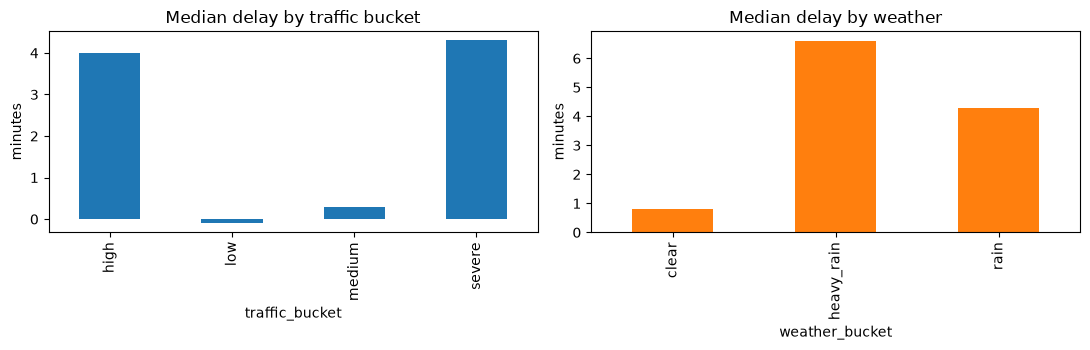

In [5]:
def summarise(df, by):
    g = df.groupby(by, observed=True)["delay_min"].agg(count="count", median="median", mean="mean").round(1)
    g["late_rate_%"] = (df.assign(l=df["delay_min"] > 0).groupby(by, observed=True)["l"].mean() * 100).round(1)
    return g

traffic_summary = summarise(valid, "traffic_bucket")
weather_summary = summarise(valid, "weather_bucket")
distance_band = pd.cut(valid["distance_km_estimate"], bins=[0, 3, 6, 10, 20, 50], include_lowest=True)
distance_summary = summarise(valid.assign(distance_band=distance_band), "distance_band")
hour_summary = summarise(valid.assign(hour=valid["created_at"].dt.hour), "hour")
display(traffic_summary); display(weather_summary); display(distance_summary); display(hour_summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
traffic_summary["median"].plot(kind="bar", ax=axes[0], title="Median delay by traffic bucket", ylabel="minutes")
weather_summary["median"].plot(kind="bar", ax=axes[1], title="Median delay by weather", ylabel="minutes", color="tab:orange")
plt.tight_layout(); plt.savefig(NB_OUT / "s5_ch2_traffic_weather.png", dpi=110); plt.show()

**Hypothesis supported by evidence:** lateness is associated with traffic (median delay −0.1 min at *low* vs +4.3 min at *severe*; late rate 49 % → 66 %) and with weather (clear +0.8 min vs heavy rain +6.6 min; late rate 53 % → 74 %). (The three `HIGH` rows were normalised into `high` before grouping — otherwise they show up as a fifth, misleading bucket.)

**Alternative explanation we cannot rule out:** traffic and weather are *buckets attached to the order*, not measured on the route; evening peaks (18:00–19:00 have the most orders and 62 % late) mean restaurant load and driver scarcity move together with traffic — the data cannot separate "roads were slow" from "the kitchen was slow". Distance shows **no** monotonic relationship (10–20 km orders have the same median delay as 6–10 km), so "long trips" is not the story either.

# Challenge 3 — Customer Support disagrees

What are customers complaining about, are ticket ids unique, and does the customer story match the operational story?

In [6]:
print("Ticket rows:", len(tickets), "| unique ticket ids:", tickets["ticket_id"].nunique(), "| duplicate ticket ids:", tickets["ticket_id"].duplicated().sum())
print("Tickets with no order id:", tickets["order_id"].isna().sum())
print("Raw categories (note casing/whitespace variants):", sorted(tickets["category"].unique()))
tickets_clean = tickets.drop_duplicates().copy()
tickets_clean["category_norm"] = tickets_clean["category"].str.strip().str.lower().str.replace(r"[\s-]+", "_", regex=True)
display(tickets_clean["category_norm"].value_counts())

# LEFT merge: tickets are the base table; we want the operational facts for every complaint
tickets_with_delay = tickets_clean.merge(valid[["order_id", "delay_min", "traffic_bucket", "weather_bucket"]], on="order_id", how="left")
assert len(tickets_with_delay) == len(tickets_clean), "join inflated the ticket count"
view = tickets_with_delay.groupby("category_norm")["delay_min"].agg(tickets="size", matched="count", median_delay="median", mean_delay="mean").round(1)
view["late_share_%"] = (tickets_with_delay.assign(l=tickets_with_delay["delay_min"] > 0).groupby("category_norm")["l"].mean() * 100).round(1)
display(view.sort_values("tickets", ascending=False))

Ticket rows: 202 | unique ticket ids: 201 | duplicate ticket ids: 1
Tickets with no order id: 3
Raw categories (note casing/whitespace variants): ['ETA issue', 'Late Delivery', 'driver_not_moving', 'eta_changed', 'late_delivery', 'late_delivery ', 'ready_but_waiting', 'restaurant_delay', 'status_mismatch']


category_norm
late_delivery        39
eta_changed          37
restaurant_delay     37
ready_but_waiting    33
status_mismatch      29
driver_not_moving    25
eta_issue             1
Name: count, dtype: int64

,tickets,matched,median_delay,mean_delay,late_share_%
category_norm,,,,,
late_delivery,39,38,14.8,12.8,84.6
restaurant_delay,37,37,10.5,9.1,75.7
eta_changed,37,35,7.7,8.7,75.7
ready_but_waiting,33,33,12.2,11.5,90.9
status_mismatch,29,28,12.7,13.8,89.7
driver_not_moving,25,25,10.4,10.7,68.0
eta_issue,1,1,5.4,5.4,100.0


**System view vs customer view**

| | Customer view (tickets) | System view (orders table) |
|---|---|---|
| Most common complaint | `late_delivery` (39) then `eta_changed` / `restaurant_delay` (37 each) | 56 % of *all* deliveries are late, so a complaint is the exception, not the rule |
| Are complaints justified? | — | Orders with a `late_delivery` ticket have a median delay of **14.8 min** vs 1.4 min overall; 87 % of them were in fact late |
| `ready_but_waiting` / `status_mismatch` | Customer sees the restaurant say *ready* while the app says *picking up* | 91–93 % of those orders were late: the driver-at-restaurant gap is real but **no arrival event exists** to measure it |
| Ticket hygiene | 1 duplicated ticket id, 3 tickets without an order id, 3 spelling variants of the category | The support system is not the canonical event log — it tells us *how the delay felt*, not *where it happened* |

**What tickets tell you that timestamps cannot:** the customer's perception of the cause (restaurant vs rider vs ETA logic) and the moment the customer lost patience — signals no operational timestamp carries.

# Challenge 4 — Dispatch API: prove you retrieved everything

Start the mock API, inspect one response, retrieve **all** pages with retries, preserve every raw page and prove completeness. A 200 on one page proves nothing.

In [7]:
import requests
from flasheats_pipeline.ingest.api_source import DispatchApiClient

API = "http://127.0.0.1:8000"
api_proc = None
try:
    requests.get(f"{API}/health", timeout=2).raise_for_status()
    print("API already running")
except Exception:
    api_proc = subprocess.Popen([sys.executable, str(BASE / "api" / "mock_dispatch_api.py")], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    for _ in range(40):
        time.sleep(0.25)
        try:
            if requests.get(f"{API}/health", timeout=2).ok:
                break
        except Exception:
            pass
print("health:", requests.get(f"{API}/health", timeout=5).json())

# one response, inspected
r = requests.get(f"{API}/dispatch/orders", params={"page": 1, "page_size": 50}, timeout=10)
payload = r.json()
print("HTTP:", r.status_code, "| keys:", list(payload), "| records on page:", len(payload["data"]), "| has_more:", payload["has_more"], "| total:", payload["total_records"])

health: {'service': 'flasheats-dispatch-api', 'status': 'ok'}
HTTP: 200 | keys: ['data', 'has_more', 'page', 'page_size', 'total_records'] | records on page: 50 | has_more: True | total: 1600


In [8]:
# reliable paginated ingestion (the same client the pipeline uses): retries 429/500, honours Retry-After, saves every raw page
client = DispatchApiClient(API, NB_OUT / "raw_dispatch", page_size=100, max_retries=4, backoff_base_s=0.2)
records, report = client.fetch_all()
print(json.dumps({k: report.as_dict()[k] for k in ["pages_fetched", "records_fetched", "unique_order_ids", "expected_total", "retries", "http_errors", "complete", "issues"]}, indent=1))
assert report.complete, "refuse to claim success when ingestion is incomplete"

dispatch_df = pd.DataFrame(records)
print("Dispatch rows:", len(dispatch_df), "| unique orders:", dispatch_df["order_id"].nunique(), "| reassigned orders:", dispatch_df["reassigned_at"].notna().sum())
print("Raw pages preserved:", len(list((NB_OUT / "raw_dispatch" / "api").glob("dispatch_page_*.json"))))
display(dispatch_df.head())

API page=3 attempt=1 HTTP 500 - retrying in 0.2s


API page=5 attempt=1 HTTP 429 - retrying in 1.0s


{
 "pages_fetched": 16,
 "records_fetched": 1600,
 "unique_order_ids": 1600,
 "expected_total": 1600,
 "retries": 2,
 "http_errors": [
  {
   "page": 3,
   "attempt": 1,
   "status": 500
  },
  {
   "page": 5,
   "attempt": 1,
   "status": 429
  }
 ],
 "complete": true,
 "issues": []
}
Dispatch rows: 1600 | unique orders: 1600 | reassigned orders: 95
Raw pages preserved: 16


,assigned_at,current_delivery_eta,dispatch_status,driver_id,estimated_pickup_at,eta_model_version,order_id,original_driver_id,reassigned_at
0,2026-08-13T13:01:09.659644,2026-08-13T14:19:15.546424,completed,D103,2026-08-13T13:14:00,eta-v3.2,O00001,D103,NaN
1,2026-08-01T18:37:09.708219,2026-08-01T20:01:16.627988,completed,D083,2026-08-01T18:54:00,eta-v3.2,O00002,D083,NaN
2,2026-08-01T19:35:00.002443,2026-08-01T20:22:59.204700,completed,D039,2026-08-01T19:53:00,eta-v3.2,O00003,D039,NaN
3,2026-08-09T18:17:16.087835,2026-08-09T19:51:58.608301,cancelled,D038,2026-08-09T18:34:00,eta-v3.2,O00004,D038,NaN
4,2026-08-06T20:36:55.346822,2026-08-06T22:13:17.537116,completed,D047,2026-08-06T20:53:00,eta-v3.1,O00005,D047,NaN


**Completeness proof:** 16 pages × 100 = **1600 records = server-reported `total_records`**, 1600 unique order ids, page 3 answered HTTP 500 and page 5 HTTP 429 on the first attempt — both were retried and the page re-fetched; every successful page is preserved as `notebooks/output/raw_dispatch/api/dispatch_page_NNN.json`. 95 orders carry a `reassigned_at`.

Cross-check with the orders table: `orders.driver_id` equals Dispatch's **original** driver for 1597 orders → the application database is **not updated after a reassignment**; Dispatch is authoritative for the final driver.

# Challenge 5 — Can we attribute the delay?

Is there a reliable *driver arrived at restaurant* event? Observed = directly stored; inferred = estimated from another signal.

In [9]:
flat_events = [{"driver_id": d["driver_id"], **e} for d in driver_events for e in d["events"]]
driver_events_df = pd.DataFrame(flat_events)
driver_events_df["timestamp"] = pd.to_datetime(driver_events_df["timestamp"], format="mixed", errors="coerce")
display(driver_events_df["type"].value_counts())
print("Explicit driver_arrived_at_restaurant events:", (driver_events_df["type"] == "arrived_at_restaurant").sum())

piv = driver_events_df[driver_events_df["type"].isin(["assigned", "picked_up", "delivered"])].groupby(["order_id", "type"])["timestamp"].min().unstack()
pings = driver_events_df[driver_events_df["type"] == "gps_ping"].merge(piv, left_on="order_id", right_index=True)
print("GPS pings before pickup:", (pings["timestamp"] <= pings["picked_up"]).sum(), "| after pickup:", (pings["timestamp"] > pings["picked_up"]).sum(),
      "| out-of-area pings (lat>13.5 or lon>78):", ((pings["lat"] > 13.5) | (pings["lon"] > 78)).sum())
print("Orders with picked_up before assigned:", (piv["picked_up"] < piv["assigned"]).sum())
print("Delivered orders in DB without actual_delivery_at that DO have a driver 'delivered' event:",
      order_analysis[(order_analysis["final_status"] == "delivered") & order_analysis["actual_delivery_at"].isna()]["order_id"].isin(piv[piv["delivered"].notna()].index).sum())

type
gps_ping     5371
assigned     1600
picked_up    1532
delivered    1532
Name: count, dtype: int64

Explicit driver_arrived_at_restaurant events: 0
GPS pings before pickup: 1632 | after pickup: 3739 | out-of-area pings (lat>13.5 or lon>78): 189
Orders with picked_up before assigned: 14
Delivered orders in DB without actual_delivery_at that DO have a driver 'delivered' event: 37


| Event / fact | Observed? | Source | Reliability concern |
|---|---|---|---|
| Driver assigned | **Observed** | Dispatch API `assigned_at`; driver app `assigned` | Two sources agree; 14 orders show `picked_up` *before* `assigned` in the driver app |
| Driver at restaurant | **Not observed** — only *inferable* | GPS pings (≈1–5 per order, 189 out-of-area outliers) near the restaurant coordinates | No stored business event; two restaurants have impossible coordinates (lat 95, lon 190); geofencing would be an estimate, not a fact |
| Picked up | **Observed** | `orders.pickup_at`; driver app `picked_up` | Agree to the second for 1527 orders; 5 orders have delivery *before* pickup |
| Delivered | **Observed** | `orders.actual_delivery_at`; driver app `delivered` | 37 delivered orders lack the DB timestamp but have the driver event |

**Conclusion:** assignment, pickup and delivery are observed; **arrival at the restaurant is not**. Restaurant preparation time and the driver's wait cannot be separated, so "was it the kitchen or the rider?" cannot be answered with the current instrumentation.

# Final FDE synthesis — one slide

1. **Problem size** — the data shows **56.4 % of 1 495 valid deliveries** arrive after the promised ETA (56.3 % on the validated population); median lateness 7.9 min, P90 delay ≈ 18 min, worst +50 min. The problem is real and large.
2. **Evidence** — lateness is associated with traffic and weather buckets and with evening peaks, not with distance. Almost all lateness accumulates **before pickup** (median pre-pickup overrun +14 min on late orders; transit is faster than planned).
3. **Trusted sources** — orders table for the promise and the delivery time; Dispatch for assignment/reassignment; driver app for movement; tickets for the customer's perception only.
4. **Uncertainty** — 37 unknown outcomes, 9 chronology violations, no restaurant-arrival event, `orders.driver_id` stale after reassignment, four competing definitions of "late" with no owner.
5. **Instrumentation recommendation** — capture *driver arrived at restaurant*, make the delivery timestamp mandatory on the `delivered` status transition, propagate reassignment into the orders table, and agree one written definition of *late* with an owner.
6. **Decision** — **do not build the AI delay predictor yet.** The model would learn from a promise that is sometimes made before the order exists, without the one event (arrival) that separates the two main causes. Fix instrumentation and the KPI definition first; the pipeline in this repository is the measurement baseline to judge any later model against.

In [10]:
# cleanup
try:
    con.close()
except Exception:
    pass
if api_proc is not None:
    api_proc.terminate()
print("Session 5 notebook complete.")

Session 5 notebook complete.
